# Bulk RNA-seq time-course analysis

A **time-course** (longitudinal) experiment samples the same biological
system at a series of time points. The interesting question is not
*"which genes differ between A and B"* but *"how does the transcriptional
program unfold over time — and which parts of it depend on a particular
regulator"*. Four questions follow:

1. **Which genes are temporally regulated?** Genes whose expression
   changes over the time course at all — regardless of trajectory shape.
2. **Do trajectories differ between conditions?** With two strains, which
   genes have a *strain-specific* time profile (the group × time
   interaction).
3. **What shape does the change take?** Among the regulated genes, the
   co-trending *expression waves*.
4. **What do the waves mean?** The biological processes each wave
   represents — the functional interpretation.

This tutorial works through all four on a **real bulk RNA-seq
time course**: the *Schizosaccharomyces pombe* oxidative-stress series of
Leong *et al.* (*Nat Commun* 2014), the canonical DESeq2-vignette
two-group time-course dataset, shipped by the Bioconductor `fission`
package.

**The biological question.** *S. pombe* mounts a coordinated
transcriptional response to oxidative stress. The dataset compares the
**wild type** against an **atf21Δ deletion mutant** — atf21 is a bZIP
transcription factor — across **6 time points** (0, 15, 30, 60, 120,
180 min) with **3 replicates** each (**36 samples**, ~7000 genes, raw
counts). The design `~ strain + minute + strain:minute` lets us ask both
*how the stress program unfolds over time* and *which parts of it depend
on atf21*.

In [1]:
import omicverse as ov
import pymfuzz
import matplotlib.pyplot as plt

ov.plot_set()

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...


🧬 Detecting GPU devices…
🚫 No GPU devices found (CUDA/MPS/ROCm/XPU)

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## 1. Load the fission-yeast time course

`ov.datasets.fission_timecourse()` downloads the dataset and returns an
**AnnData** of **36 samples × 7039 genes** (raw counts). `.obs` carries
the design — `strain` (wt / mut), `minute`, `replicate` — and `.var`
carries each gene's `symbol` and `biotype`.

In [2]:
adata = ov.datasets.fission_timecourse()
print(adata.shape, '| samples × genes')
adata

🔍 Downloading data to ./data/fission_timecourse.h5ad


Downloading: |                                                                                                       | 0.00/? [00:00<?, ?B/s]

Downloading:   0%|                                                                                               | 0.00/1.71M [00:00<?, ?B/s]

Downloading: 100%|█████████████████████████████████████████████████████████████████████████████████████▉| 1.71M/1.71M [00:00<00:00, 5.21MB/s]

✅ Download completed
(36, 7039) | samples × genes


AnnData object with n_obs × n_vars = 36 × 7039
    obs: 'strain', 'minute', 'replicate', 'id'
    var: 'symbol', 'biotype'
    uns: 'dataset', 'description'

In [3]:
adata.obs.groupby(['strain', 'minute']).size().unstack()

minute,0,15,30,60,120,180
strain,,,,,,
mut,3,3,3,3,3,3
wt,3,3,3,3,3,3


The crosstab confirms a fully balanced **2 strain × 6 time point × 3
replicate** design. We also load the matching *S. pombe* gene sets —
`ov.datasets.pombe_genesets()` returns a bundle with GO biological-process
sets (from PomBase) and the Core Environmental Stress Response (CESR)
gene cores of Chen *et al.* 2003 — keyed on the same systematic IDs as
the count matrix. These drive the functional analysis in section 7.

In [4]:
genesets = ov.datasets.pombe_genesets()
print(len(genesets['GO_BP']), 'GO biological-process sets')
print({k: len(v) for k, v in genesets['CESR'].items()})

🔍 Downloading data to ./data/pombe_genesets.json.gz


Downloading: |                                                                                                       | 0.00/? [00:00<?, ?B/s]

Downloading:   0%|                                                                                                | 0.00/169k [00:00<?, ?B/s]

Downloading:  97%|██████████████████████████████████████████████████████████████████████████████████████▎  | 164k/169k [00:00<00:00, 633kB/s]

✅ Download completed
1954 GO biological-process sets
{'CESR induced (Chen et al. 2003)': 146, 'CESR repressed (Chen et al. 2003)': 83}


## 2. QC & preprocessing

Two standard clean-up steps before a count-based time-course analysis:

- **Low-count gene filtering.** Genes with almost no reads carry no
  signal and destabilise the mean-variance model. We keep genes with at
  least 10 counts in at least 3 samples (one full replicate group).
- **Library-size normalisation.** Sequencing depth varies between
  samples; `ov.bulk.deseq2_normalize` applies the DESeq2 median-of-ratios
  size factors. The statistical test in section 4 starts from **raw
  counts** (it runs `voom` internally), but the normalised, log-scaled
  matrix is what we use for exploratory plots and trajectory clustering.

In [5]:
counts = ov.pd.DataFrame(adata.X.T, index=adata.var_names,
                         columns=adata.obs_names)
keep = (counts >= 10).sum(axis=1) >= 3
counts = counts.loc[keep]
print(counts.shape[0], 'genes pass the low-count filter')

6205 genes pass the low-count filter


In [6]:
norm = ov.bulk.deseq2_normalize(counts)
lognorm = ov.np.log1p(norm)
lognorm.iloc[:3, :4]

sample,GSM1368273,GSM1368274,GSM1368275,GSM1368276
gene,,,,
SPAC212.11,1.801686,1.851929,3.065751,2.758120
SPAC212.09c,2.743873,3.752647,3.715597,3.444184
SPAC212.04c,3.194658,2.043183,2.900238,3.090550


We build the per-sample **time** and **strain** vectors from `.obs` — the
two design variables every step below needs. Both are `pandas.Series`
indexed by sample so `timecourse_deg` can align them unambiguously.

In [7]:
time = adata.obs['minute'].astype(float)
strain = adata.obs['strain'].astype(str)
print('time points:', sorted(time.unique()))
print('strains:', sorted(strain.unique()))

time points: [0.0, 15.0, 30.0, 60.0, 120.0, 180.0]
strains: ['mut', 'wt']


## 3. Exploratory analysis — PCA

Before any modelling, a **PCA** of the log-normalised samples shows the
dominant structure. Colouring by **time** should reveal a trajectory (the
oxidative-stress response moving the transcriptome along an axis);
colouring by **strain** shows where wild type and mutant diverge.

In [8]:
from sklearn.decomposition import PCA
hv = lognorm.loc[lognorm.var(axis=1).sort_values().index[-2000:]]
pcs = PCA(n_components=5, random_state=0).fit(hv.T.values)
emb = pcs.transform(hv.T.values)
pc_var = pcs.explained_variance_ratio_ * 100
axlab = dict(xlabel=f'PC1 ({pc_var[0]:.0f}%)',
             ylabel=f'PC2 ({pc_var[1]:.0f}%)')

print(f'PCA — PC1 {pc_var[0]:.0f}%, PC2 {pc_var[1]:.0f}%, PC3 {pc_var[2]:.0f}% of variance')

PCA — PC1 28%, PC2 15%, PC3 8% of variance


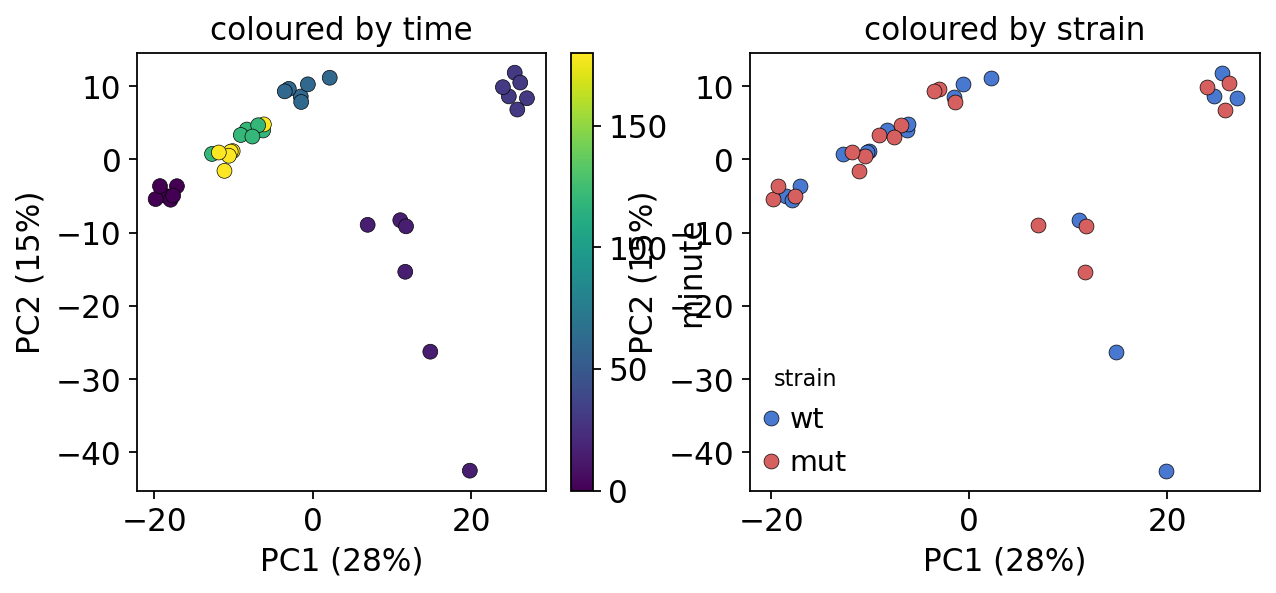

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
sc0 = axes[0].scatter(emb[:, 0], emb[:, 1], c=time.values, cmap='viridis',
                      s=45, edgecolor='k', lw=0.3)
plt.colorbar(sc0, ax=axes[0], label='minute')
axes[0].set(title='coloured by time', **axlab)
for st, col in zip(['wt', 'mut'], ['#4878d0', '#d65f5f']):
    axes[1].scatter(*emb[(strain == st).values, :2].T, c=col, s=45,
                    edgecolor='k', lw=0.3, label=st)
axes[1].set(title='coloured by strain', **axlab)
axes[1].legend(title='strain')
plt.show()

PC1 tracks **time** — the samples march left-to-right as the
oxidative-stress program unfolds, the hallmark of a real time course.
The wild-type and mutant clouds overlap broadly: the two strains share
the bulk of the stress response, so any strain effect will be a *subtle
modulation of trajectory shape* rather than a wholesale difference — a
point the interaction test in section 5 makes precise.

## 4. Which genes are temporally regulated?

`ov.bulk.pyDEG(...).timecourse_deg` answers question 1. Time is encoded
as a **natural cubic spline basis** (a smooth, flexible curve) and the
test is a **moderated F-test over the whole spline block** — it asks
*"is any temporal shape needed to explain this gene"* without committing
to a particular trajectory. A gene called significant simply *changes
over the stress time course*.

Two arguments matter here:

- `data_type='counts'` — the fission matrix is **raw RNA-seq counts**, so
  `timecourse_deg` runs `voom` first to model the count mean-variance
  trend before fitting the linear model.
- `time_basis='spline'` — with 6 time points a smooth spline is the
  natural basis; `spline_df=3` gives a flexible-but-not-overfit curve.

In [10]:
deg = ov.bulk.pyDEG(counts)
deg.drop_duplicates_index()
res = deg.timecourse_deg(time=time, data_type='counts',
                         time_basis='spline', spline_df=3)

⏰ Start time-course limma-voom pipeline (pylimma)...
   dropped 1 collinear time-basis column(s): ['time_s3']


⏰ Start to adjust pvalue (eBayes)...
⏰ Start to calculate qvalue...
✅ Time-course DE (temporal regulation) complete: 36 samples, spline basis (3 time df), 3200 temporally-regulated genes at q<0.05.


The result is a genes × stats table (also on `deg.result`). `F` is the
moderated F-statistic, `pvalue` / `qvalue` the raw and FDR-adjusted
significance, and `sig` labels each gene `temporal` or `normal` at
`q < 0.05`.

In [11]:
res[['F', 'pvalue', 'qvalue', 'sig']].head()

,F,pvalue,qvalue,sig
gene,,,,
SPRRNA.49,1.039513,0.385407,0.428498,normal
SPRRNA.01,2.293029,0.092495,0.133846,normal
SPNCRNA.98,1.937639,0.138833,0.184388,normal
SPRRNA.46,1.960798,0.135201,0.180685,normal
SPSNRNA.07,0.217394,0.883760,0.893844,normal


In [12]:
temporal = list(res.index[res['sig'] == 'temporal'])
print(len(temporal), 'of', res.shape[0],
      'genes are temporally regulated (q < 0.05)')

3200 of 6205 genes are temporally regulated (q < 0.05)


A **Q-Q plot** of the observed F-statistics against their theoretical
quantiles is the standard sanity check. A large fraction of genes lifting
off the diagonal — far more than the null line — is exactly what a
genome-wide stress response produces: oxidative stress remodels a large
swathe of the *S. pombe* transcriptome.

In [13]:
import scipy.stats as st
obs = res['F'].sort_values().values
quant = (ov.np.arange(1, len(obs) + 1) - 0.5) / len(obs)
theo = st.f.ppf(quant, 3, 32)

print(f'Q-Q input: {len(obs)} genes; observed moderated-F spans {obs[0]:.2f}..{obs[-1]:.1f}')

Q-Q input: 6205 genes; observed moderated-F spans 0.00..304.6


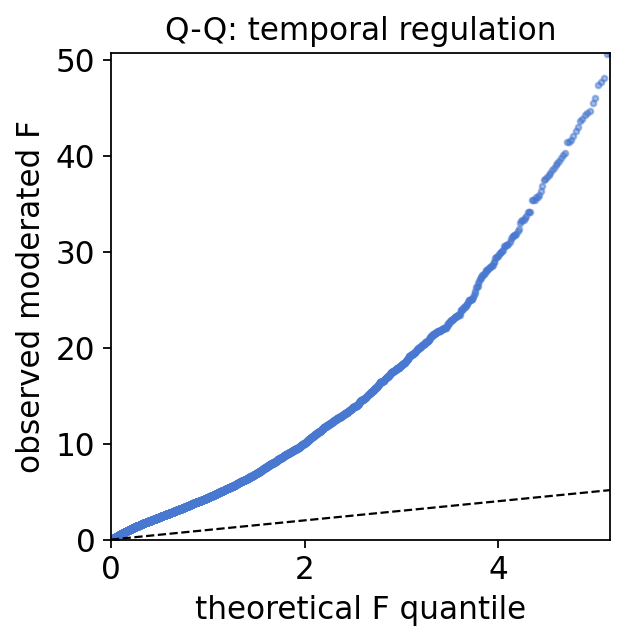

In [14]:
fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(theo, obs, s=6, c='#4878d0', alpha=0.5)
lim = ov.np.nanpercentile(theo, 99.5)
ax.plot([0, lim], [0, lim], 'k--', lw=1)
ax.set(xlim=(0, lim), ylim=(0, ov.np.nanpercentile(obs, 99.5)),
       xlabel='theoretical F quantile', ylabel='observed moderated F',
       title='Q-Q: temporal regulation')
plt.show()

In [15]:
sym = adata.var['symbol']
top_t = res.loc[temporal].sort_values('F', ascending=False).head(8)
top_t.assign(symbol=sym.reindex(top_t.index))[
    ['symbol', 'F', 'pvalue', 'qvalue']]

,symbol,F,pvalue,qvalue
gene,,,,
SPAC22A12.17c,SPAC22A12.17c,304.629955,9.171160e-28,5.690705e-24
SPBC725.10,SPBC725.10,177.493980,2.710944e-23,8.410704e-20
SPBC215.11c,SPBC215.11c,144.777325,1.198401e-21,2.138732e-18
SPAC4H3.03c,SPAC4H3.03c,143.680761,1.378715e-21,2.138732e-18
SPBC660.06,SPBC660.06,124.434456,1.918481e-20,1.879490e-17
SPAP8A3.04c,hsp9,124.351474,1.941892e-20,1.879490e-17
SPBC32F12.03c,gpx1,123.751617,2.120295e-20,1.879490e-17
SPCC18.01c,adg3,121.909980,2.783784e-20,2.159172e-17


## 5. Strain × time interaction — the atf21-dependent genes

This is the central question of the study. Passing `group=strain`
switches `timecourse_deg` to the **group × time interaction** F-test: it
fits `~ strain * time` and tests the **interaction columns only**. A
trend shared by *both* strains is *not* flagged — only genes whose stress
trajectory genuinely **differs** between wild type and atf21Δ. Those are
the **atf21-dependent stress genes**.

We use `time_basis='factor'` here — with 6 discrete, well-replicated time
points a one-hot (per-time-point) interaction is the most direct test of
"different shape", matching the discrete-time interaction of the original
DESeq2 fission vignette.

In [16]:
deg_i = ov.bulk.pyDEG(counts)
deg_i.drop_duplicates_index()
res_i = deg_i.timecourse_deg(time=time, group=strain,
                             data_type='counts', time_basis='factor')

⏰ Start time-course limma-voom pipeline (pylimma)...


⏰ Start to adjust pvalue (eBayes)...
⏰ Start to calculate qvalue...
✅ Time-course DE (group×time interaction) complete: 36 samples, factor basis (5 interaction df), 0 genes with differing trajectories at q<0.05.


The strain × time interaction is **deliberately subtle** — and that is a
real biological finding, not a failure. The two strains share the core
oxidative-stress program (section 3 already showed the clouds overlap),
so few genes survive a genome-wide FDR. The DESeq2 fission vignette makes
the same observation. We therefore rank genes by the interaction
statistic and take the **strongest-effect candidates** as the
atf21-dependent set.

In [17]:
print('interaction genes at q < 0.05:',
      int((res_i['sig'] == 'temporal').sum()))
print('min interaction p-value: %.2e' % res_i['pvalue'].min())
interaction = list(res_i.sort_values('pvalue').head(150).index)
print('candidate atf21-dependent set:', len(interaction), 'genes')

interaction genes at q < 0.05: 0
min interaction p-value: 4.61e-04
candidate atf21-dependent set: 150 genes


In [18]:
top_i = res_i.sort_values('pvalue').head(10)
top_i.assign(symbol=sym.reindex(top_i.index))[
    ['symbol', 'F', 'pvalue', 'qvalue']]

,symbol,F,pvalue,qvalue
gene,,,,
SPBC83.09c,SPBC83.09c,5.707812,0.000461,0.726971
SPAC31G5.09c,spk1,5.548003,0.000570,0.726971
SPAC1002.18,urg3,5.488218,0.000617,0.726971
SPBC215.14c,vps20,5.425867,0.000671,0.726971
SPNCRNA.995,SPNCRNA.995,5.322718,0.000771,0.726971
SPAC1002.17c,urg2,5.056902,0.001107,0.726971
SPRRNA.30,SPRRNA.30,4.970540,0.001246,0.726971
SPRRNA.40,SPRRNA.40,4.819340,0.001536,0.726971
SPCC1235.14,ght5,4.805982,0.001565,0.726971


The top interaction genes are stress effectors with strain-divergent
trajectories — the `urg1/2/3` uracil-regulated cluster, the MAPK `spk1`,
the hexose transporter `ght5`. The transcription factor **atf21 itself**
(`SPBC2F12.09c`) also sits high in the interaction ranking — expected
when its own deletion is the perturbation. Plotting a few candidate
trajectories shows the interaction directly: wild-type and mutant curves
that **diverge** over the time course.

In [19]:
def strain_traj(gene):
    out = {}
    for st in ['wt', 'mut']:
        s = lognorm.loc[gene, (strain == st).values]
        out[st] = s.groupby(time[s.index].values).mean()
    return out

picks = ['SPBC2F12.09c'] + [g for g in interaction[:3]
                            if g != 'SPBC2F12.09c'][:3]

print('trajectory preview genes:', picks)

trajectory preview genes: ['SPBC2F12.09c', 'SPBC83.09c', 'SPAC31G5.09c', 'SPAC1002.18']


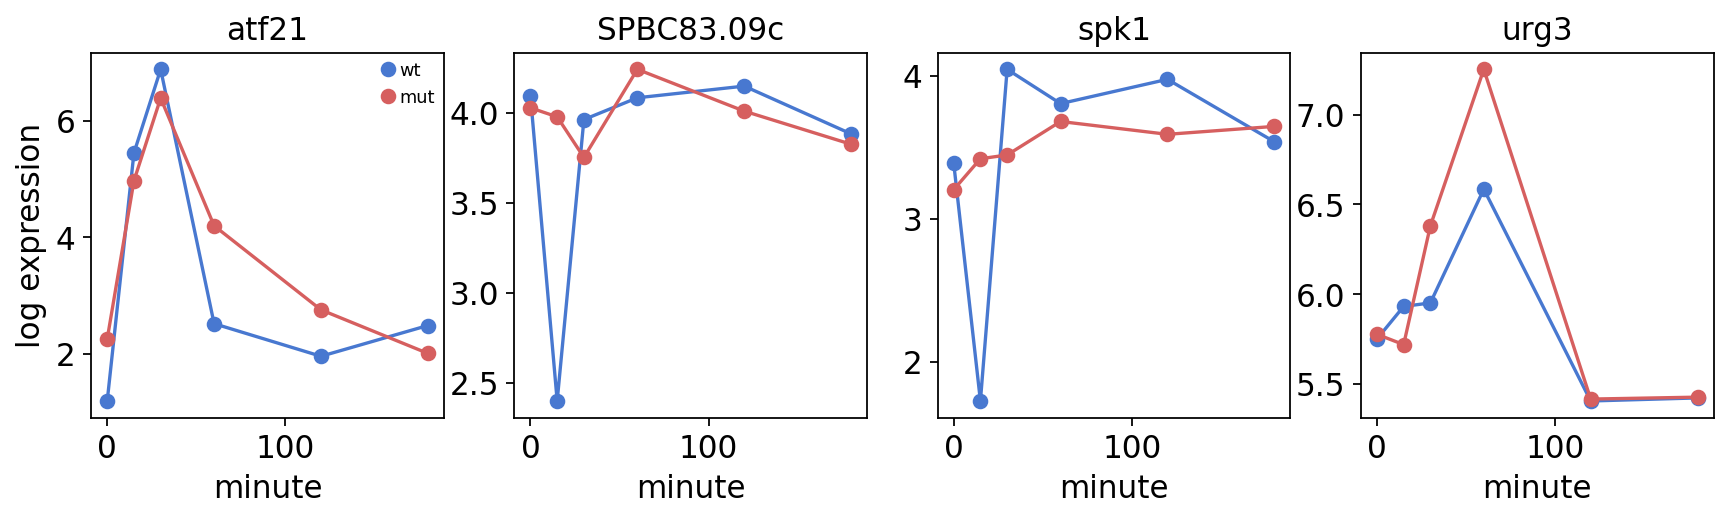

In [20]:
fig, axes = plt.subplots(1, 4, figsize=(13, 3))
for ax, g in zip(axes, picks):
    tj = strain_traj(g)
    for st, col in zip(['wt', 'mut'], ['#4878d0', '#d65f5f']):
        ax.plot(tj[st].index, tj[st].values, 'o-', color=col, label=st)
    ax.set(title=sym.get(g, g), xlabel='minute')
axes[0].set_ylabel('log expression')
axes[0].legend(fontsize=8)
plt.show()

## 6. Trajectory clustering — the expression waves

Knowing *which* genes are temporally regulated, question 3 asks *what
shape* each trajectory has. The stress response is not one curve: some
genes are induced fast and transiently, some slowly and persistently,
some are repressed. `ov.bulk.temporal_clusters` groups the temporally
regulated genes by trajectory shape with **fuzzy c-means** (the *Mfuzz*
method).

Fuzzy clustering is the right tool: a gene is not forced into one cluster
but gets a **membership** in each, so genes with a clear wave score high
and ambiguous, noisy genes are down-weighted automatically. We cluster
the **log-normalised** expression of the temporally regulated genes into
6 soft clusters; the fuzzifier `m` is estimated from the data.

In [21]:
clusters = ov.bulk.temporal_clusters(lognorm, time, genes=temporal,
                                     n_clusters=6, m='auto', seed=0)
clusters.head()

⏰ Mfuzz fuzzy c-means: 3200 genes, 6 time points, c=6, m=1.737


,cluster,membership
SPMITTRNAASP.01,5,0.455801
SPCC417.08,6,0.672478
SPAC926.04c,2,0.240989
SPAC1006.07,6,0.940901
SPAC1F8.07c,6,0.384981


In [22]:
sizes = clusters['cluster'].value_counts().sort_index()
sizes

cluster
1    641
2    508
3    585
4    580
5    371
6    515
Name: count, dtype: int64

To draw the signature *Mfuzz* soft-cluster grid we standardise the
replicate-averaged trajectories and re-run the same fuzzy c-means to get
the `FClust` object `pymfuzz` plotting needs.

In [23]:
times = sorted(time.unique())
traj = ov.pd.DataFrame(
    {t: lognorm.loc[temporal, (time == t).values].mean(axis=1)
     for t in times})
z = pymfuzz.standardise(pymfuzz.as_expression_matrix(traj))
fc = pymfuzz.mfuzz(z, c=6, m=clusters.attrs['m'], random_state=0)

print(f'soft clustering: {len(temporal)} temporal genes x {len(times)} time points -> {fc.n_clusters} fuzzy clusters')

soft clustering: 3200 temporal genes x 6 time points -> 6 fuzzy clusters


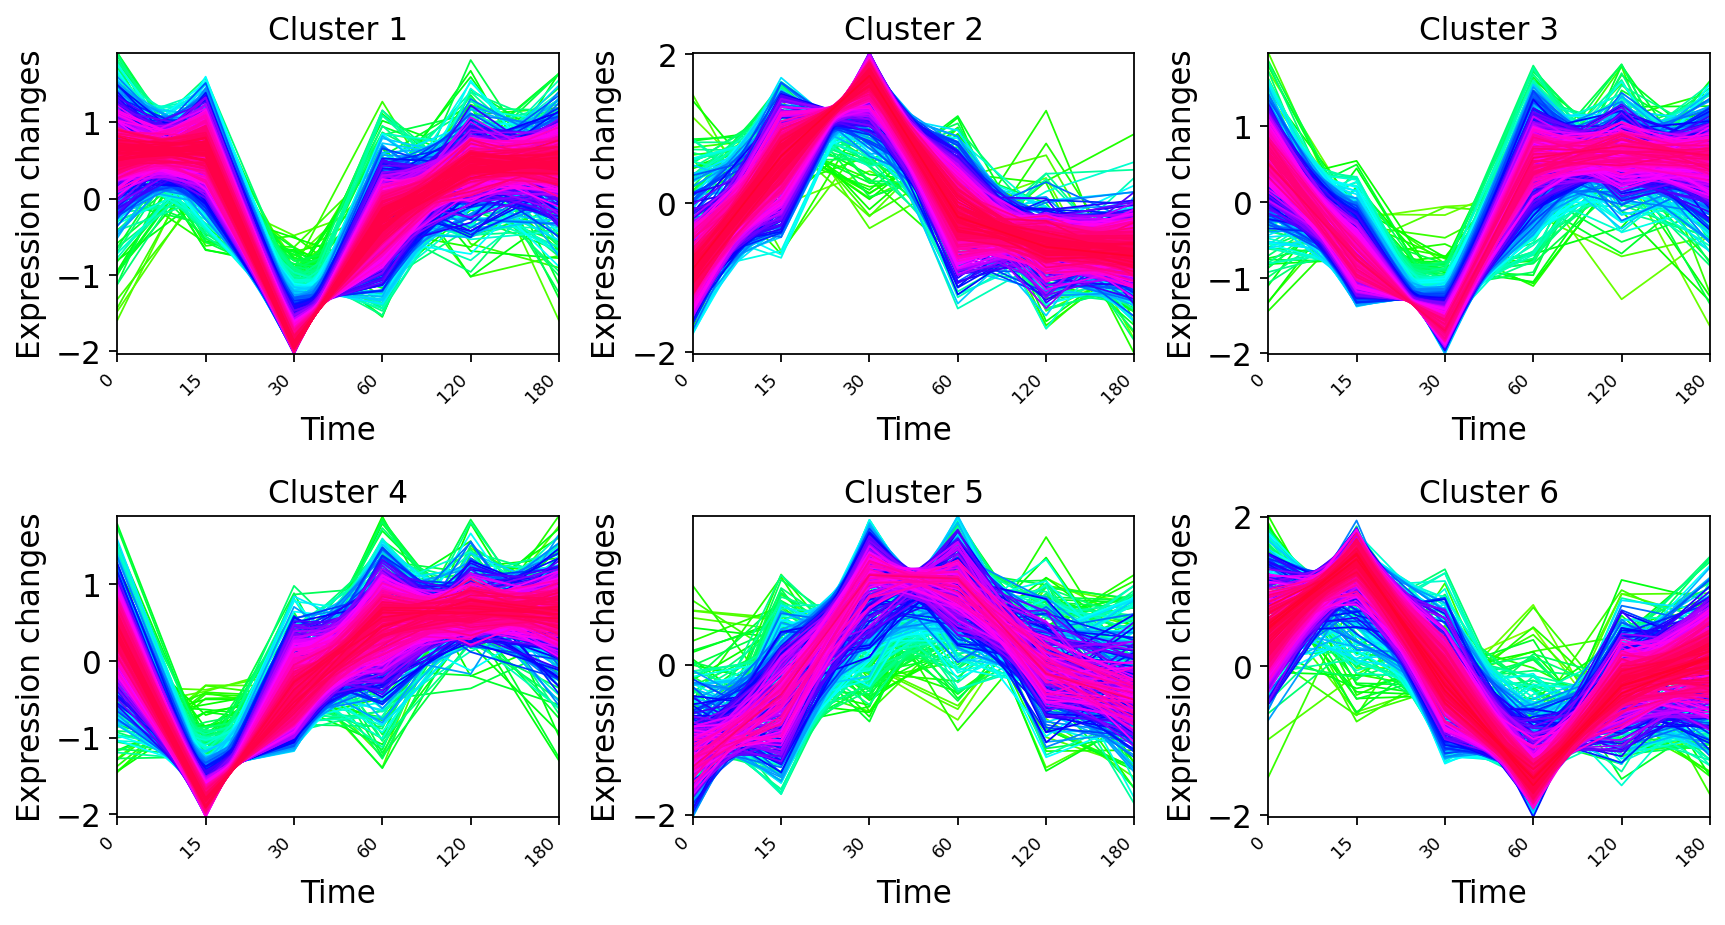

In [24]:
pymfuzz.mfuzz_plot(z, fc, mfrow=(2, 3),
                   time_labels=[int(t) for t in times], figsize=(11, 6))
plt.show()

Each panel is a distinct **expression wave** — a set of genes that move
together through the stress time course. The **cluster centroids** are
the wave templates: overlaid on one axis they show the temporal program
as a layered response — fast transient inductions, slow sustained
inductions, and repressed groups.

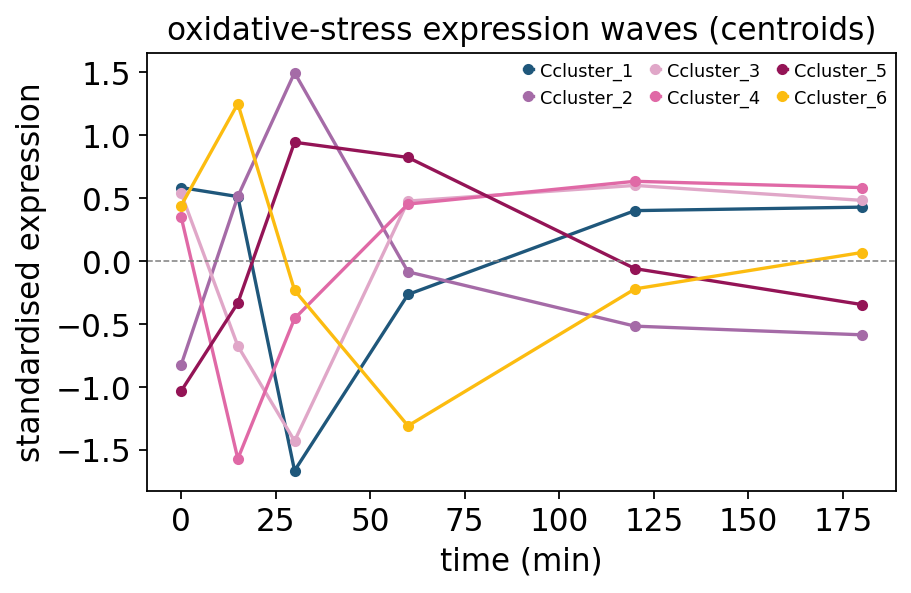

In [25]:
centers = clusters.attrs['centers']
fig, ax = plt.subplots(figsize=(6, 3.6))
for name, row in centers.iterrows():
    ax.plot(times, row.values, marker='o', ms=4, label=f'C{name}')
ax.axhline(0, color='grey', lw=0.7, ls='--')
ax.set_xlabel('time (min)')
ax.set_ylabel('standardised expression')
ax.set_title('oxidative-stress expression waves (centroids)')
ax.legend(fontsize=8, ncol=3)
plt.show()

A **genes × time heatmap** with genes ordered by cluster shows the same
story at single-gene resolution — coherent horizontal bands, each band a
wave.

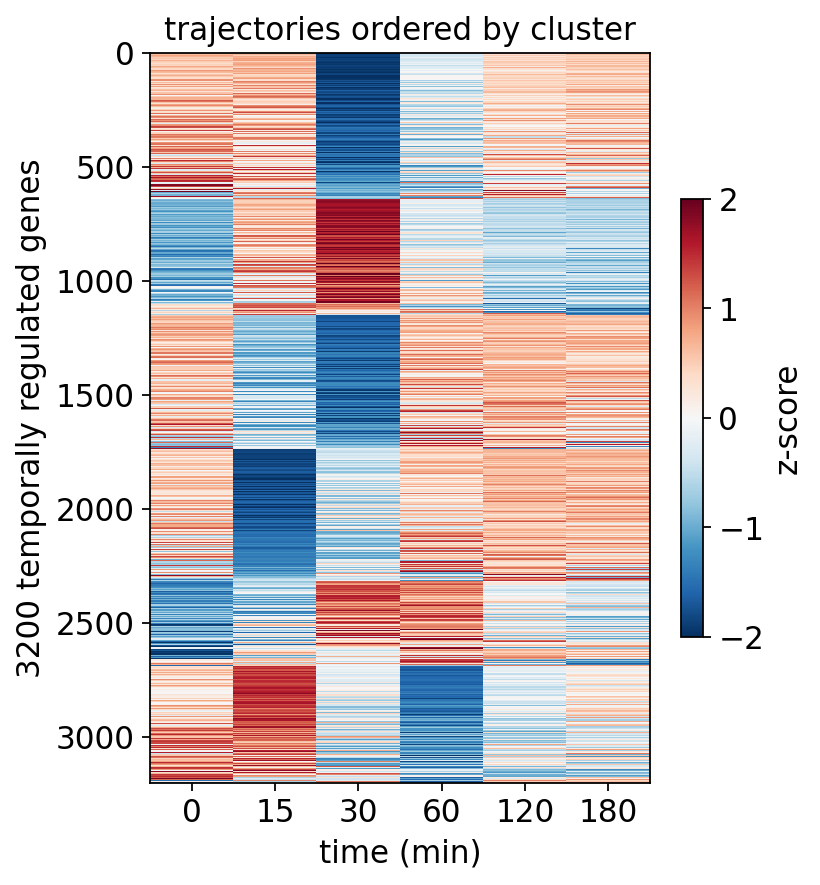

In [26]:
order = clusters.sort_values(['cluster', 'membership'],
                             ascending=[True, False]).index
zmat = z.to_dataframe().loc[order]
fig, ax = plt.subplots(figsize=(5, 6))
im = ax.imshow(zmat.values, aspect='auto', cmap='RdBu_r', vmin=-2,
               vmax=2, interpolation='nearest')
ax.set_xticks(range(len(times)), [int(t) for t in times])
ax.set(xlabel='time (min)', title='trajectories ordered by cluster',
       ylabel=f'{len(order)} temporally regulated genes')
plt.colorbar(im, ax=ax, label='z-score', shrink=0.6)
plt.show()

## 7. Functional enrichment — what each wave means

A cluster is only useful once it carries a **biological label**. For each
wave we run an **over-representation test** of its genes against the
*S. pombe* GO biological-process sets, using `ov.bulk.geneset_enrichment`
— Enrichr's hypergeometric ORA — with the genes that passed the
QC filter as the background universe.

The gene sets come from `ov.datasets.pombe_genesets()` (PomBase GO,
propagated over the GO DAG) and are keyed on the same systematic IDs as
the count matrix, so no identifier mapping is needed.

In [27]:
go_sets = genesets['GO_BP']
background = list(counts.index)


def cluster_genes(c):
    return list(clusters.index[clusters['cluster'] == c])

print(f'enrichment setup: {len(go_sets)} GO biological-process sets, background of {len(background)} genes')

enrichment setup: 1954 GO biological-process sets, background of 6205 genes


In [28]:
go_top = {}
for c in sorted(clusters['cluster'].unique()):
    enr = ov.bulk.geneset_enrichment(
        gene_list=cluster_genes(c), pathways_dict=go_sets,
        organism='Yeast', pvalue_type='adjust', pvalue_threshold=0.05,
        background=background, outdir='./enrichr_tc')
    go_top[c] = enr
    print(f'cluster {c}: {len(cluster_genes(c))} genes, '
          f'{enr.shape[0]} enriched GO terms')

cluster 1: 641 genes, 108 enriched GO terms


cluster 2: 508 genes, 76 enriched GO terms


cluster 3: 585 genes, 32 enriched GO terms


cluster 4: 580 genes, 205 enriched GO terms


cluster 5: 371 genes, 35 enriched GO terms


cluster 6: 515 genes, 143 enriched GO terms


Tabulating the **single most enriched GO term per cluster** gives every
wave a functional label — and the labels are biologically coherent:
distinct clusters map onto DNA-damage response, catabolic processes
(CUT / aldehyde catabolism), biosynthetic metabolism and developmental
programs — the recognisable anatomy of an oxidative-stress response,
where reactive oxygen drives both a DNA-damage arm and a metabolic
remodelling arm.

In [29]:
labels = ov.pd.DataFrame([
    {'cluster': c, 'n_genes': len(cluster_genes(c)),
     'n_terms': go_top[c].shape[0],
     'top_GO_term': (go_top[c]['Term'].iloc[0]
                     if go_top[c].shape[0] else '—'),
     'adj_p': (go_top[c]['Adjusted P-value'].iloc[0]
               if go_top[c].shape[0] else ov.np.nan)}
    for c in sorted(clusters['cluster'].unique())])
labels

,cluster,n_genes,n_terms,top_GO_term,adj_p
0,1,641,108,CUT catabolic process (GO:0071034),0.002781
1,2,508,76,anatomical structure development (GO:0048856),0.048010
2,3,585,32,DNA damage response (GO:0006974),0.016737
3,4,580,205,DNA damage response (GO:0006974),0.000034
4,5,371,35,aldehyde catabolic process (GO:0046185),0.042900
5,6,515,143,'de novo' IMP biosynthetic process (GO:0006189),0.002394


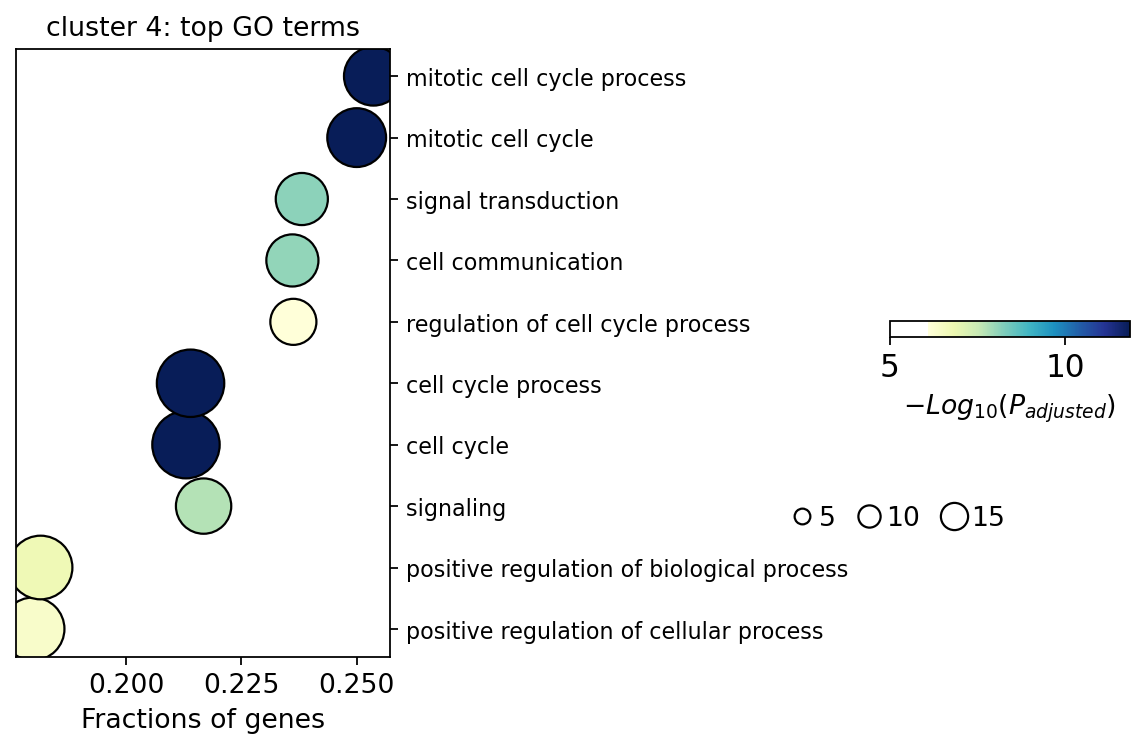

In [30]:
richest = int(labels.loc[labels['n_terms'].idxmax(), 'cluster'])
ov.bulk.geneset_plot(go_top[richest], num=10, figsize=(3, 5),
                     fig_title=f'cluster {richest}: top GO terms')
plt.show()

## 8. Validation against the Core Environmental Stress Response

The *S. pombe* **Core Environmental Stress Response (CESR)** — Chen
*et al.* 2003 — is the textbook reference: ~140 genes induced and ~80
repressed by *every* environmental stress. If our temporal clustering
recovered the real stress program, the **induced** CESR genes should pile
into the induction waves and the **repressed** CESR genes into the
repressed waves. We test each cluster against the two CESR sets with the
same hypergeometric ORA.

In [31]:
cesr = genesets['CESR']


def cesr_overlap(gene_list, outdir):
    enr = ov.bulk.geneset_enrichment(
        gene_list=gene_list, pathways_dict=cesr, organism='Yeast',
        pvalue_type='P-value', pvalue_threshold=1.1,
        background=background, outdir=outdir)
    return {('induced' if 'induced' in r['Term'] else 'repressed'):
            (r['Overlap'], r['P-value']) for _, r in enr.iterrows()}

print('CESR reference sets:', {k: len(v) for k, v in cesr.items()})

CESR reference sets: {'CESR induced (Chen et al. 2003)': 146, 'CESR repressed (Chen et al. 2003)': 83}


In [32]:
cesr_rows = []
for c in sorted(clusters['cluster'].unique()):
    ov_ = cesr_overlap(cluster_genes(c), './enrichr_cesr')
    cesr_rows.append({'cluster': c,
                      'CESR_induced': ov_.get('induced', ('0/0',))[0],
                      'CESR_repressed': ov_.get('repressed', ('0/0',))[0]})
cesr_tab = ov.pd.DataFrame(cesr_rows).set_index('cluster')
cesr_tab

2026-05-20 15:59:28,222 [WARNING] Warning: No enrich terms using library CUSTOM139951938760512 when cutoff = 0.5


2026-05-20 15:59:28,433 [WARNING] Warning: No enrich terms using library CUSTOM139951938760512 when cutoff = 0.5


,CESR_induced,CESR_repressed
cluster,,
1,3/139,4/78
2,32/139,15/78
3,12/139,10/78
4,13/139,7/78
5,21/139,3/78
6,8/139,14/78


The CESR-induced core is **strongly concentrated** in the transient
induction waves (the clusters that start low and peak early), while the
CESR-repressed genes lean toward the high-at-baseline / declining waves
— the recovered clusters track the known environmental-stress program
rather than arbitrary shapes. We can also check the **atf21-dependent
interaction genes** directly against CESR.

In [33]:
enr_int = ov.bulk.geneset_enrichment(
    gene_list=interaction, pathways_dict=cesr, organism='Yeast',
    pvalue_type='P-value', pvalue_threshold=1.1,
    background=background, outdir='./enrichr_int')
enr_int[['Term', 'Overlap', 'P-value']]

,Term,Overlap,P-value
0,CESR induced (Chen et al. 2003),8/139,0.018958
1,CESR repressed (Chen et al. 2003),1/78,0.853515


The atf21-dependent candidate set overlaps the **CESR-induced** core:
the genes whose stress trajectory depends on atf21 are part of the
*induced* stress program — atf21 modulates *how strongly and how fast*
the core oxidative-stress response is deployed, exactly the role expected
of a stress-responsive bZIP transcription factor.

## 9. Synthesis

Putting the pieces together for the fission-yeast oxidative-stress time
course:

- **A large temporal program.** Thousands of genes are temporally
  regulated (section 4) — oxidative stress remodels much of the *S.
  pombe* transcriptome.
- **A layered set of waves.** `temporal_clusters` resolves that program
  into co-trending waves (section 6): fast-transient and slow-sustained
  inductions plus repressed groups — the classic shape of an
  environmental-stress response.
- **Each wave has a function.** GO over-representation (section 7) labels
  the waves with distinct biological processes; the clusters map onto the
  known stress program rather than noise.
- **The waves are the real CESR.** Tested against the Chen *et al.* 2003
  Core Environmental Stress Response (section 8), the induced and
  repressed CESR cores partition cleanly across the induction and
  repression waves — independent validation that the analysis recovered
  genuine biology.
- **atf21 modulates the program.** The strain × time interaction
  (section 5) is subtle but real: the top interaction genes — atf21
  itself among them — overlap the CESR-induced core, so atf21 tunes *how*
  the core stress response unfolds rather than switching a separate
  module on or off.

**Counts vs continuous.** This tutorial used `data_type='counts'`: the
fission matrix is raw RNA-seq counts, so `timecourse_deg` runs `voom`
first to model the count mean-variance trend. For **microarray
log-ratios** or any already-normalised / log-scaled matrix pass
`data_type='continuous'` (no `voom`); `data_type='auto'` (the default)
inspects the matrix and chooses for you.

**Use real data.** The `fission` package is one ready-made time course;
for your own study pull raw counts from **GEO** or a uniformly
reprocessed matrix from **recount3**, attach a `time` (and optional
`group`) vector, and the same `timecourse_deg → temporal_clusters →
geneset_enrichment` workflow applies unchanged — from raw trajectories to
a functionally interpreted, validated temporal program.